In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

print("Downloading data...")
data = fetch_openml(name='credit-g', version=1, as_frame=True, parser='auto')
df = data.frame
df['target'] = df['class'].apply(lambda x: 0 if x == 'good' else 1)
df = df.drop(columns=['class'])
print("Success! Data loaded. Shape:", df.shape)

Success! Data loaded. Shape: (1000, 21)


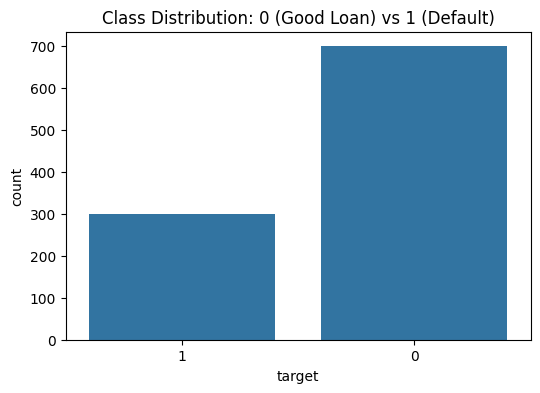

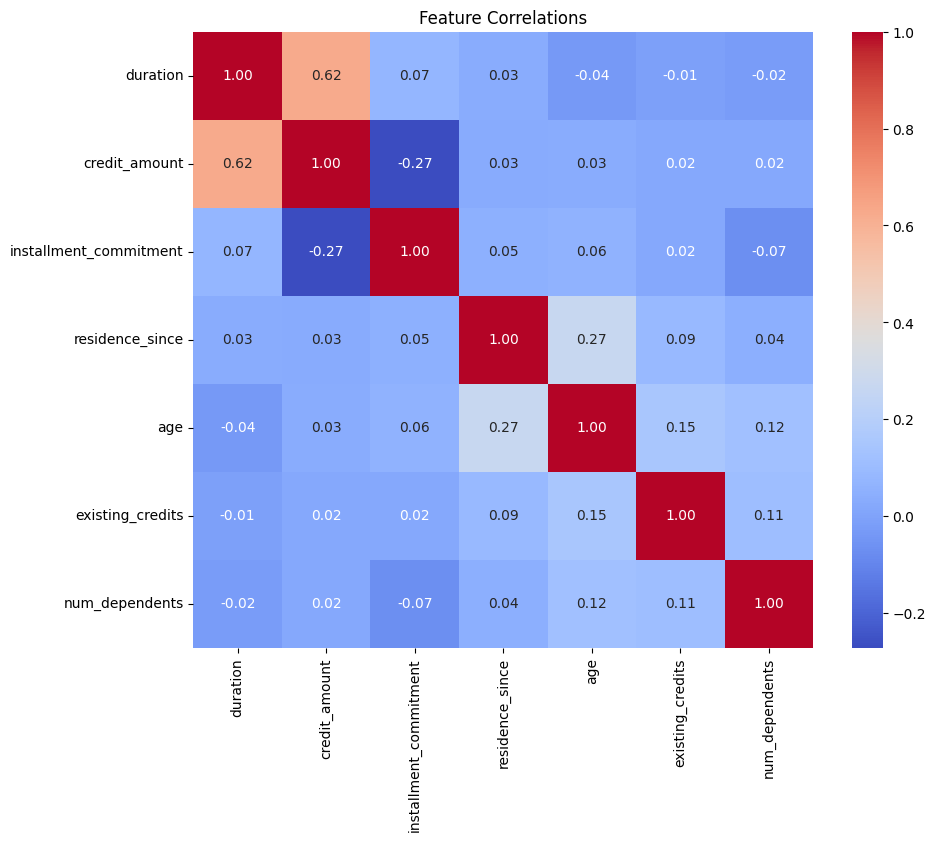

In [4]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='target')
plt.title("Class Distribution: 0 (Good Loan) vs 1 (Default)")
plt.show()

plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlations")
plt.show()

In [5]:
X = df.drop(columns=['target'])
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['category', 'object']).columns

numeric_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
categorical_transformer = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
preprocessor = ColumnTransformer([('num', numeric_transformer, numeric_features), ('cat', categorical_transformer, categorical_features)])

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', max_depth=5),
    "XGBoost": XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=42)
}

trained_models = {}
for name, model in models.items():
    clf = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
    clf.fit(X_train, y_train)
    y_prob = clf.predict_proba(X_test)[:, 1]
    print(f"{name} ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
    trained_models[name] = clf

Logistic Regression ROC-AUC Score: 0.8058
Decision Tree ROC-AUC Score: 0.5990
XGBoost ROC-AUC Score: 0.7569



--- GLOBAL EXPLANATION (Portfolio Level) ---


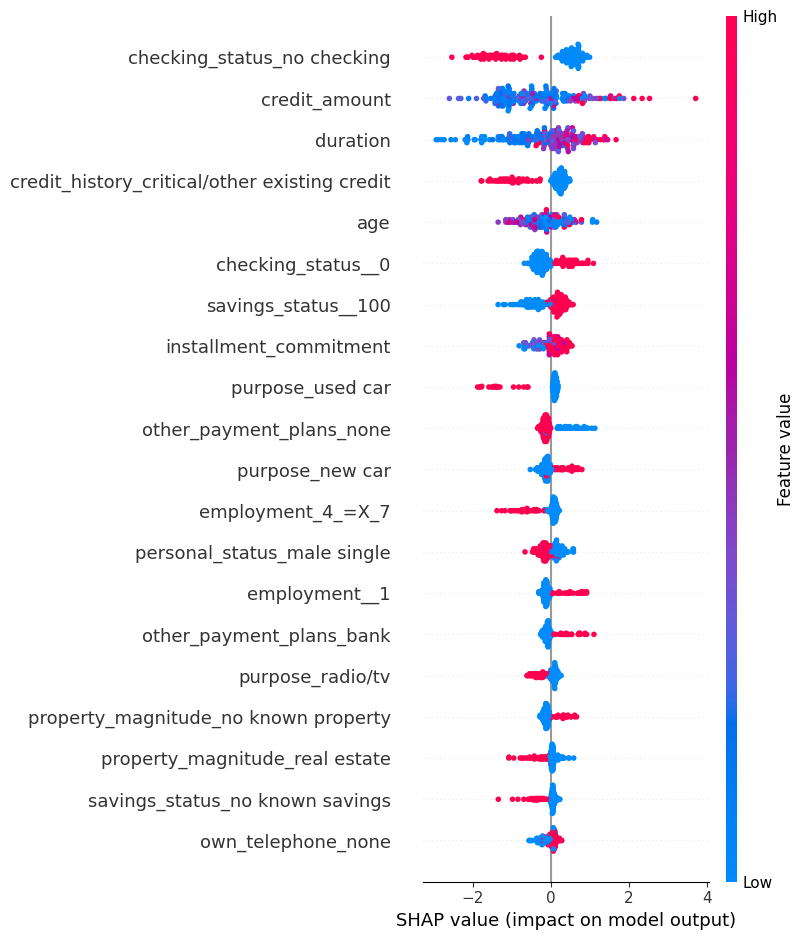


--- LOCAL EXPLANATION (Applicant #0) ---


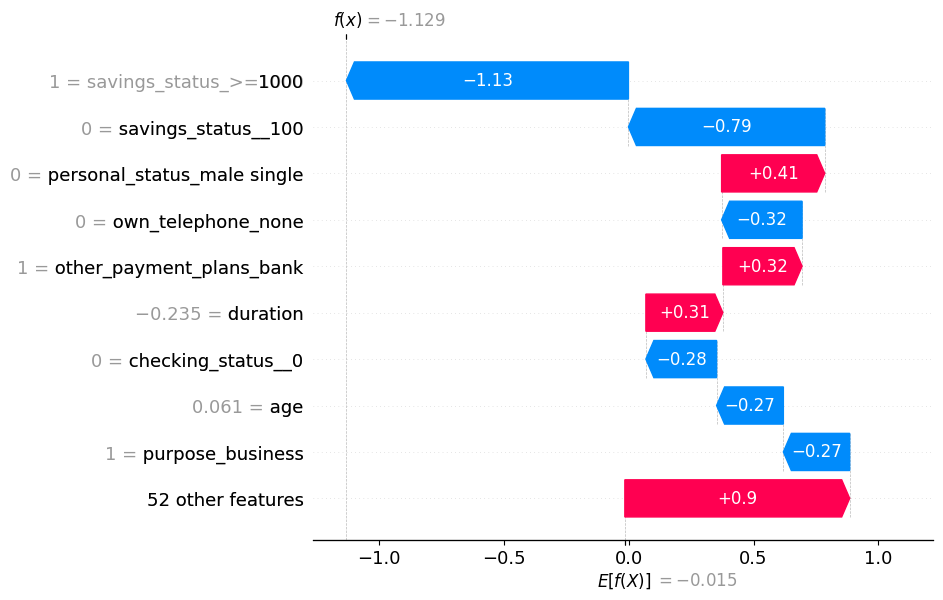

In [7]:
xgb_pipeline = trained_models["XGBoost"]
preprocessor_fitted = xgb_pipeline.named_steps['preprocessor']
xgb_model = xgb_pipeline.named_steps['classifier']

cat_encoder = preprocessor_fitted.named_transformers_['cat'].named_steps['onehot']
cat_features_encoded = cat_encoder.get_feature_names_out(categorical_features)
all_feature_names = list(numeric_features) + list(cat_features_encoded)

X_test_transformed = preprocessor_fitted.transform(X_test)
X_test_df = pd.DataFrame(X_test_transformed, columns=all_feature_names)

# Sanitize column names by replacing [, ], and < with an underscore
X_test_df.columns = [
    col.replace('[', '_').replace(']', '_').replace('<', '_') 
    for col in X_test_df.columns
]

# Now the SHAP call should work without a hitch
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test_df)

print("\n--- GLOBAL EXPLANATION (Portfolio Level) ---")
shap.summary_plot(shap_values, X_test_df)

applicant_idx = 0 
print(f"\n--- LOCAL EXPLANATION (Applicant #{applicant_idx}) ---")
shap.plots.waterfall(shap_values[applicant_idx])